# Exploring AAPL Stock Data with Pandas and Matplotlib

In this assignment, you will use `AAPL.csv` to practice basic data inspection, summary statistics, and plotting with Pandas and Matplotlib.

The dataset contains daily Apple stock price data with the columns `date`, `adj_close`, `close`, `high`, `low`, `open`, `volume`, and `symbol`.

For each exercise, write your code between the `# <START>` and `# <END>` comments. 


In [10]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')


## Exercise 1: Load and Inspect the Dataset

Read `AAPL.csv` into a DataFrame named `df`. Then display:

- The first 10 rows
- The shape of the dataset
- The column names
- The data types of each column


In [11]:
# <START>
# Read AAPL.csv into df
df = pd.read_csv('AAPL.csv')

# Display the first 10 rows
print(df.head(10))

# Display the shape, columns, and data types
print(df.shape)
print(df.columns)
print(df.dtypes)

# <END>


         date  adj_close      close       high        low       open  \
0  2015-01-02  24.192606  27.332500  27.860001  26.837500  27.847500   
1  2015-01-05  23.511055  26.562500  27.162500  26.352501  27.072500   
2  2015-01-06  23.513268  26.565001  26.857500  26.157499  26.635000   
3  2015-01-07  23.842981  26.937500  27.049999  26.674999  26.799999   
4  2015-01-08  24.759077  27.972500  28.037500  27.174999  27.307501   
5  2015-01-09  24.785631  28.002501  28.312500  27.552500  28.167500   
6  2015-01-12  24.174902  27.312500  28.157499  27.200001  28.150000   
7  2015-01-13  24.389544  27.555000  28.200001  27.227501  27.857500   
8  2015-01-14  24.296606  27.450001  27.622499  27.125000  27.260000   
9  2015-01-15  23.637186  26.705000  27.514999  26.665001  27.500000   

      volume symbol  
0  212818400   AAPL  
1  257142000   AAPL  
2  263188400   AAPL  
3  160423600   AAPL  
4  237458000   AAPL  
5  214798000   AAPL  
6  198603200   AAPL  
7  268367600   AAPL  
8  195826

## Exercise 2: Convert and Sort Dates

The `date` column is currently read as text. Convert it to a datetime column, sort the rows by date, and reset the index.

After sorting, display the earliest date and latest date in the dataset.


In [52]:
# <START>
# Convert date column to datetime
df["date"]=pd.to_datetime(df["date"])


# Sort by date and reset the index
df.sort_values("date", inplace=True)
df.reset_index(drop=True,inplace=True)
print(df)

# Display the first and last dates
print(df.head(1))
print(df.tail(1))
# <END>


           date   adj_close       close        high         low        open  \
0    2015-01-02   24.192606   27.332500   27.860001   26.837500   27.847500   
1    2015-01-05   23.511055   26.562500   27.162500   26.352501   27.072500   
2    2015-01-06   23.513268   26.565001   26.857500   26.157499   26.635000   
3    2015-01-07   23.842981   26.937500   27.049999   26.674999   26.799999   
4    2015-01-08   24.759077   27.972500   28.037500   27.174999   27.307501   
...         ...         ...         ...         ...         ...         ...   
2853 2026-05-08  293.050018  293.320007  294.760010  290.000000  290.010010   
2854 2026-05-11  292.679993  292.679993  293.880005  290.230011  291.980011   
2855 2026-05-12  294.799988  294.799988  295.269989  292.559998  292.559998   
2856 2026-05-13  298.869995  298.869995  300.920013  293.500000  293.500000   
2857 2026-05-14  298.209991  298.209991  300.350006  295.380005  299.820007   

         volume symbol  daily_range       ma_20    

## Exercise 3: Summary Statistics

Find the mean, standard deviation, highest value, and lowest value for these numerical columns:

- `open`
- `high`
- `low`
- `close`
- `adj_close`
- `volume`

Store the result in a variable named `summary_stats` and display it.


In [23]:
numeric_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']

# <START>
# Calculate mean, standard deviation, minimum, and maximum
summary_stats = {"mean" : df[numeric_cols].mean(),
                 "standard_deviation" : df[numeric_cols].std(),
                 "min" : df[numeric_cols].min(),
                 "max" : df[numeric_cols].max()}
# Display summary_stats
print(pd.DataFrame(summary_stats))

# <END>


                   mean  standard_deviation           min           max
open       1.135603e+02        7.763993e+01  2.250000e+01  2.998200e+02
high       1.147901e+02        7.846975e+01  2.291750e+01  3.009200e+02
low        1.124226e+02        7.688940e+01  2.236750e+01  2.953800e+02
close      1.136598e+02        7.771770e+01  2.258500e+01  2.988700e+02
adj_close  1.112138e+02        7.815784e+01  2.056587e+01  2.988700e+02
volume     1.093330e+08        6.794444e+07  1.791060e+07  6.488252e+08


## Exercise 4: Highest and Lowest Adjusted Close

Find the row where Apple had the highest `adj_close` price and the row where it had the lowest `adj_close` price.

Display the `date`, `adj_close`, and `volume` for both rows.


In [29]:
# <START>
# Find the index of the highest and lowest adjusted close values
high_index = df["adj_close"].idxmax()
low_index = df["adj_close"].idxmin()


# Select date, adj_close, and volume for both rows
a = ["date", "adj_close", "volume"]
ha = df.loc[high_index,a]
la = df.loc[low_index,a]

print('Highest adjusted close:',ha)

print('Lowest adjusted close:',la)

# <END>


Highest adjusted close: date         2026-05-13 00:00:00
adj_close             298.869995
volume                  52684300
Name: 2856, dtype: object
Lowest adjusted close: date         2016-05-12 00:00:00
adj_close               20.56587
volume                 305258800
Name: 342, dtype: object


## Exercise 5: Plot Date vs Adjusted Close

Create a line plot showing how `adj_close` changes over time.

Your plot should include:

- Figure size `(12, 5)`
- A blue line
- Title: `AAPL Adjusted Close Price Over Time`
- X-axis label: `Date`
- Y-axis label: `Adjusted Close Price`


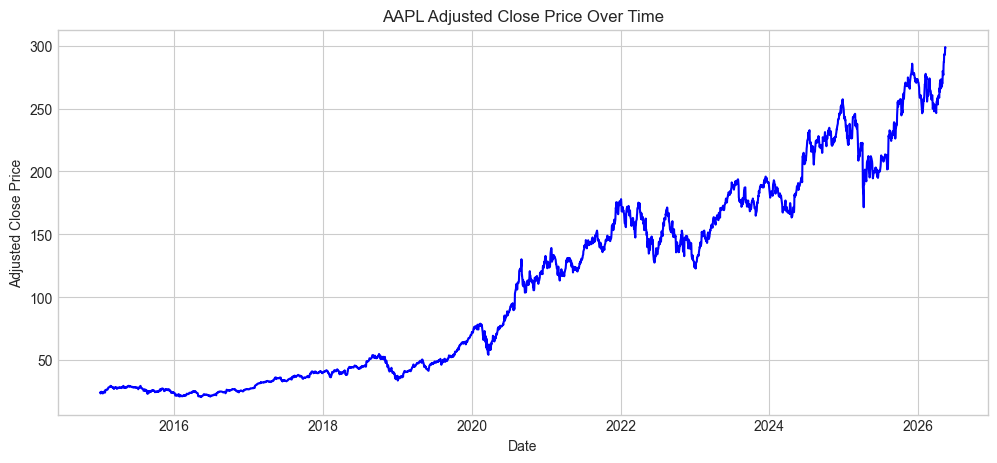

In [30]:
# <START>
plt.figure(figsize=(12,5))
plt.plot(df["date"],df["adj_close"],color='blue')
plt.title("AAPL Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()
# <END>


## Exercise 6: Plot Trading Volume Over Time

Create a line plot for `volume` over time.

Your plot should include:

- Figure size `(12, 5)`
- A purple line
- Title: `AAPL Trading Volume Over Time`
- X-axis label: `Date`
- Y-axis label: `Volume`


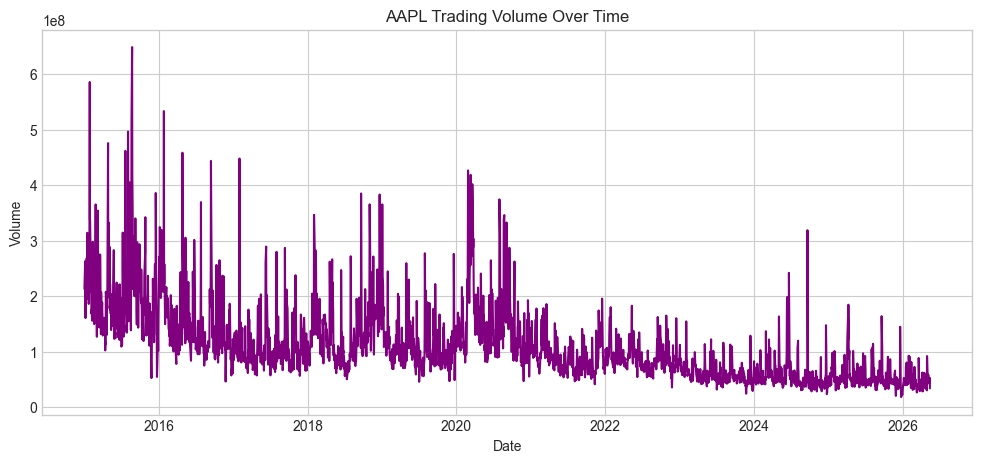

In [31]:
# <START>
plt.figure(figsize=(12,5))
plt.plot(df["date"],df["volume"],color='purple')
plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()
# <END>


## Exercise 7: Top 10 Highest Volume Days

Find the 10 days with the highest trading volume and store them in `top_volume_days`.

Then create a bar chart with:

- `date` on the X-axis
- `volume` on the Y-axis
- Title: `Top 10 AAPL Trading Volume Days`
- Rotated X-axis labels so the dates are readable


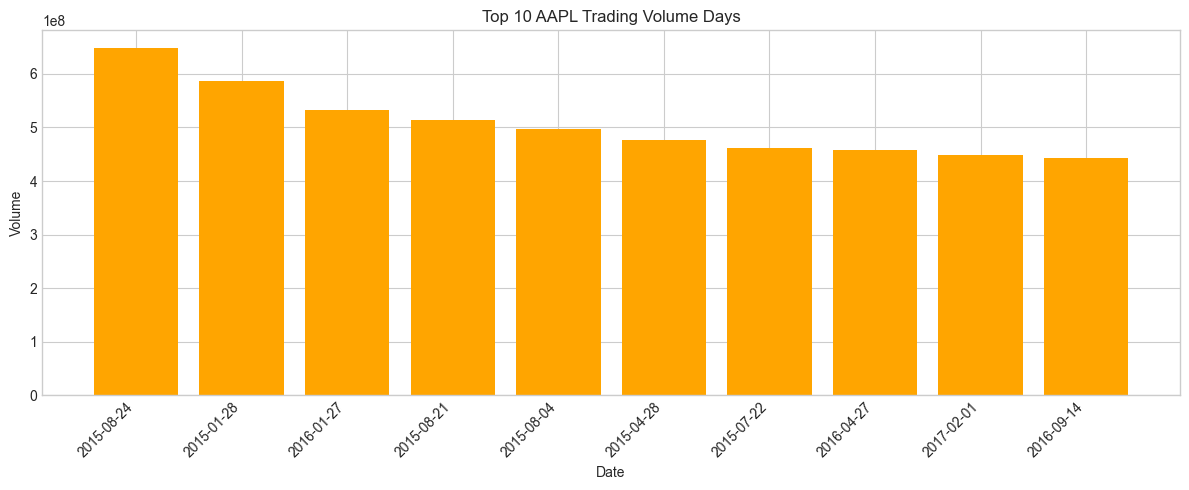

In [43]:
# <START>
# Find the 10 highest volume days
temp =df.copy()
top_volume_days=temp.sort_values("volume", ascending=False).head(10)

# Plot the result
plt.figure(figsize=(12, 5))
plt.bar(top_volume_days['date'].dt.strftime('%Y-%m-%d'), top_volume_days['volume'], color='orange')
plt.title('Top 10 AAPL Trading Volume Days')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# <END>


## Exercise 8: Moving Average Plot

Create two new columns:

- `ma_20`: 20-day moving average of `adj_close`
- `ma_50`: 50-day moving average of `adj_close`

Then plot `adj_close`, `ma_20`, and `ma_50` on the same graph.


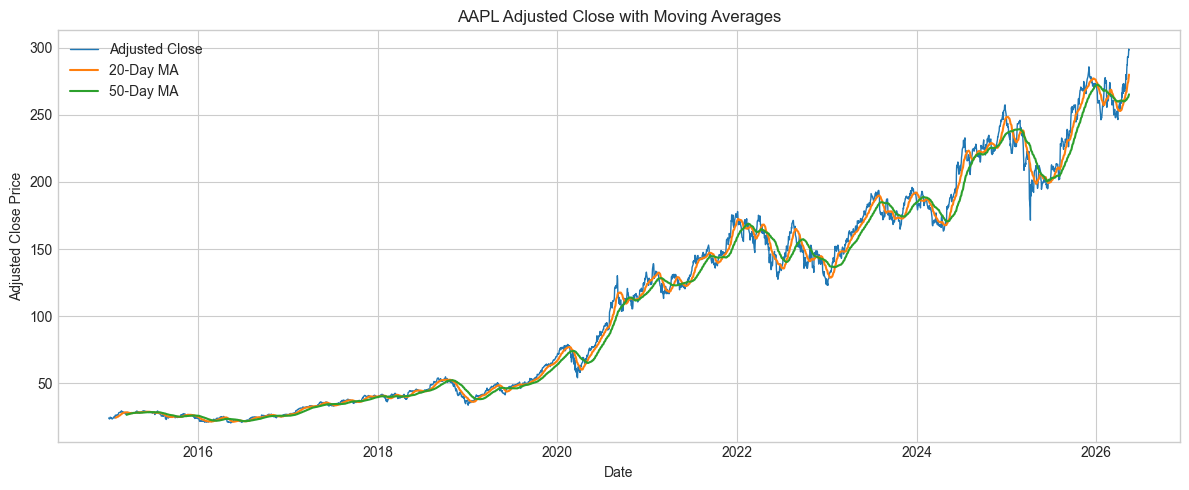

In [48]:
# <START>
# Calculate moving averages
df['ma_20']=df['adj_close'].rolling(window=20).mean()
df['ma_50']=df['adj_close'].rolling(window=50).mean()
# Plot adjusted close and moving averages
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['adj_close'], label='Adjusted Close', linewidth=1)
plt.plot(df['date'], df['ma_20'], label='20-Day MA', linewidth=1.5)
plt.plot(df['date'], df['ma_50'], label='50-Day MA', linewidth=1.5)
plt.title('AAPL Adjusted Close with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()
# <END>


## Exercise 9: Relationship Between Daily Range and Volume

Create a new column named `daily_range` using:

`daily_range = high - low`

Then make a scatter plot with `daily_range` on the X-axis and `volume` on the Y-axis.


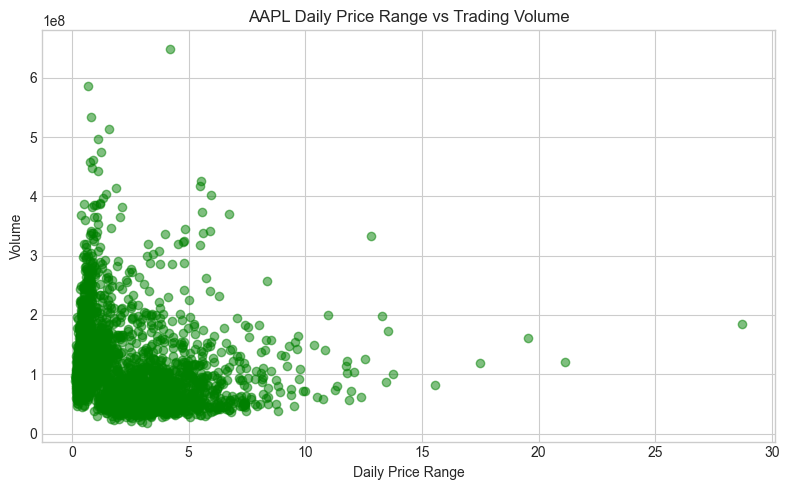

In [47]:
# <START>
# Calculate daily range
df["daily_range"]=df["high"]-df["low"]
# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['daily_range'], df['volume'], alpha=0.5, color='green')
plt.title('AAPL Daily Price Range vs Trading Volume')
plt.xlabel('Daily Price Range')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()
# <END>


## Bonus Exercise: Monthly Average Adjusted Close

Group the data by month and calculate the average `adj_close` for each month. Plot the monthly averages as a line plot.

Hint: Use `df.set_index('date').resample('ME')`.


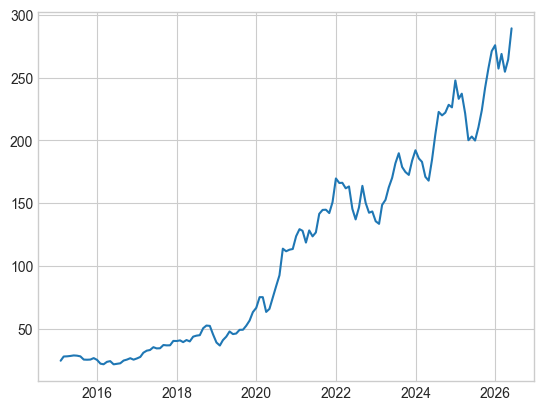

In [57]:
# <START>
# Calculate monthly average adjusted close
monthly=df.set_index('date')['adj_close'].resample('ME').mean()

# Plot monthly average adjusted close
plt.plot(monthly.index,monthly.values)
# <END>
